# 0 - Importando bibliotecas
---

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo seed para resultados replicáveis
rng = np.random.default_rng(42)

# 1 - Regressão linear univariada
---
### 1.1 - Introdução
A ideia é a partir de uma série de pontos $(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)$ calcular uma reta que melhor se encaixa a esses pontos.

<br>

Equação geral da reta: 

$$
\boxed{
y = b + w*x \tag{1}
}
$$

Nessa equação há duas váriaveis a dependente, $y$, e uma independente, $x$. De acordo com a equação 1, e com o que foi proposto, o problema se resume a encontrar $b$ e $w$ tal que:

$$
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix} =
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b\\
w
\end{bmatrix}
$$

Porém a igualdade só irá ser verdade se a reta passar exatamente sobre tais pontos, em um problema real isso é muito improvável. Portanto adicionando um termo de erro $[e_1, e_2, ..., e_n]^T$:

$$
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix} =
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b\\
w
\end{bmatrix} +
\begin{bmatrix}
e_1\\
e_2\\
\vdots \\
e_n
\end{bmatrix}
$$

e assim:

$$
\boxed{
\begin{bmatrix}
e_1\\
e_2\\
\vdots \\
e_n
\end{bmatrix} = 
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix} - 
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b\\
w
\end{bmatrix} \tag{2}
}
$$

Então a ideia por trás da regressão linear, replicavél para mais de uma váriavel independente, é reduzir ao máximo o vetor de erros.

Para melhor vizualizar as contas:

$$
e = 
\begin{bmatrix}
e_1\\
e_2\\
\vdots \\
e_n
\end{bmatrix} \qquad
d = 
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix} \qquad
X = 
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n;
\end{bmatrix} \qquad
W = 
\begin{bmatrix}
b\\
w
\end{bmatrix}
$$

### 1.2 - Criando testes
Nessa seção é definido todos os dados para fazer os testes nas seções posteriores, considerando que os valores de $d$ são os da função original acrescentado de um ruído para cada coordenada $x$.

Valores escolhidos b = 2.6916419044025126 e w = 3.6162988752555396


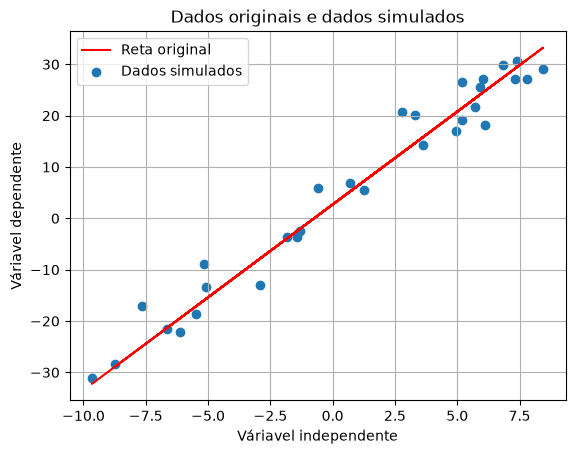

In [35]:
# Definindo reta original
W = np.random.uniform(-10, 10, (2, 1))
print(f"Valores escolhidos b = {W[0, 0]} e w = {W[1, 0]}")

# Definindo amostragem com ruído
n_amostras = 30
rng = np.random.default_rng()
ruido = rng.normal(0, 5, (n_amostras, 1)) #N(0,1)

# Montando data sets
x =  np.random.uniform(-10, 10, (n_amostras, 1))
X =  np.hstack((np.ones((n_amostras, 1)), x))
y =  X@W # Na prática não se sabe, nem o formato
d =  X@W + ruido # Na prática é o que se sabe

# Montando gráfico
plt.plot(x, y, label = "Reta original", color = "red")
plt.scatter(x, d, label = "Dados simulados")

plt.xlabel("Váriavel independente")
plt.ylabel("Váriavel dependente")
plt.legend()
plt.title("Dados originais e dados simulados")
plt.grid(True)
plt.show()

### 1.3 - Minimizando erro
A ideia é utilizar a bordagem dos mínimos quadrados para calcular o erro e, para o problema em questão, utilizar cálculo derivar a expressão do erro e igualar chegando em um sistema te equações cuja solução é um $W$ que minimiza o erro.

Método dos mínimos quadrados:
$$
\sum_{i = 1}^{n} e_i^2 = \sum_{i = 1}^{n} (d_i - b - wx_i)^2
$$

$$
\frac{\partial}{\partial b}
\left(
\sum_{i=1}^{n}(d_i-b-wx_i)^2
\right)
=
-2\sum_{i=1}^{n}(d_i-b-wx_i)
=
-2\sum_{i=1}^{n}e_i
$$

$$
\frac{\partial}{\partial w}
\left(
\sum_{i=1}^{n}(d_i-b-wx_i)^2
\right)
=
-2\sum_{i=1}^{n}x_i(d_i-b-wx_i)
=
-2\sum_{i=1}^{n}x_ie_i
$$

Juntando as duas expressões em uma por meio de matrizes:

$$
\frac{\partial}{\partial W}
\left(
\sum_{i=1}^{n}(e_i)^2
\right)
=
-2X^Te
=
-2X^T(d - XW)
$$

Igualando esse resultado a zero o $W$ correspondente pode ser calculado e os valores de b e w serão tais que esse ponto é necessariamente um mínimo, pois a função custo é a soma de termos quadráticos, que é sempre não negativa e convexa, nomeando a solução do sistema de equação como $W_0$, $b_0$ e $w_0$:

$$
-2X^T(d - XW_0) = 0
$$

$$
X^Td - X^TXW_0 = 0
$$

$$
\boxed{
X^TXW_0 = X^Td \tag{3}
}
$$

Assim, com $W_0 = \begin{bmatrix} b_0 \\ w_0 \end{bmatrix}$,  $b_0$ e $w_0$ aplicados na equação 1 geram a reta que melhor se ajusta aos pontos segundo os critério dos mínimos quadrados.

### 1.4 - Gerando resultados
Simplesmente resolvendo os sistema pelo numpy

In [31]:
W0 = np.linalg.solve(X.T@X, X.T@d)

In [32]:
print(
    f"Da reta original:\nb = {W[0,0]}\nw = {W[1,0]}\n"
    f"\nDos mínimos quadrados:\nb0 = {W0[0,0]}\nw0 = {W0[1,0]}"
)

Da reta original:
b = -6.374844684695402
w = 4.806546849466313

Dos mínimos quadrados:
b0 = -4.725973112039705
w0 = 4.714724559489311


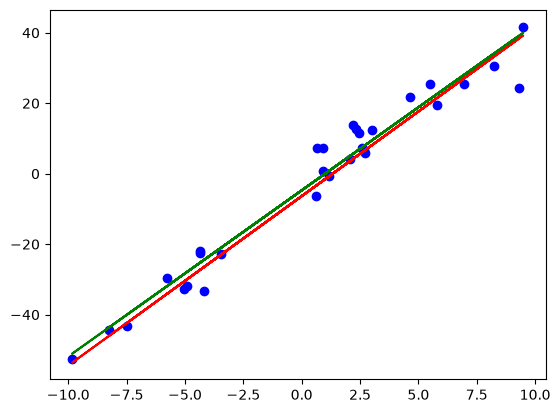

Erro final = 83.29590265232294


In [34]:
# Plotando resultado
y_0 = X@W0
plt.plot(x, y, color = "red") # Reta original
plt.plot(x, y_0, color = "green") # Reta calculada
plt.scatter(x, d, color = "blue") # Pontos do data set
plt.show()

erro_final = np.sum((y - y_0)**2)
print(f"Erro final = {erro_final}")

A maioria dos conceitos apresentados aqui também é utilizada no estudo e na aplicação de redes neurais. Foi proposital o uso de (b) e (w) na Equação (1), pois esses parâmetros correspondem ao viés (bias) e ao peso (weight), respectivamente, nomenclatura amplamente utilizada em aprendizado de máquina.

Além disso, o conjunto de dados utilizado para calcular a reta foi tratado como um único conjunto de pontos. Em uma aplicação prática, esse conjunto normalmente é dividido em duas partes: conjunto de treino, utilizado para ajustar os parâmetros do modelo (encontrar a reta), e conjunto de testes, utilizado apenas para avaliar o desempenho do modelo em dados que não foram usados durante o treinamento.

Por fim, este exemplo apresenta apenas o caso mais simples de regressão linear. Apesar disso, os conceitos de função custo, minimização do erro, ajuste de parâmetros e representação matricial servem como base para algoritmos mais avançados, incluindo regressão múltipla, regressão logística e redes neurais artificiais.


# 2 - Regressão linear multivariada
---
### 2.1 - Introdução
Por uma simetria do problema todo o resultado obtido pela seção 1 pode ser aplicado para o caso em que multiplas variáveis estão envolvidas seguindo as seguinte ampliações:

Os pontos são multidimencionais, $n$ pontos com $m$ características: 

$$
(x_{11}, x_{12}, \ldots, x_{1m}, y_1),\;
(x_{21}, x_{22}, \ldots, x_{2m}, y_2),\;
\ldots,\;
(x_{N1}, x_{N2}, \ldots, x_{Nm}, y_N)
$$

A equação 1 não se torna:

$$
\boxed{
y = b + w_1x_1 + w_2x_2 + \cdots + w_mx_m \tag{4}
}
$$

A equação 2 se torna: 

$$
\boxed{
\begin{bmatrix}
e_1\\
e_2\\
\vdots\\
e_n
\end{bmatrix}
=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
-
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1m}\\
1 & x_{21} & x_{22} & \cdots & x_{2m}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{nm}
\end{bmatrix}
\begin{bmatrix}
b\\
w_1\\
w_2\\
\vdots\\
w_m
\end{bmatrix}
\tag{5}
}
$$

Com: 

$$
e = 
\begin{bmatrix}
e_1\\
e_2\\
\vdots\\
e_n
\end{bmatrix}
\qquad
d =
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
\qquad
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1m}\\
1 & x_{21} & x_{22} & \cdots & x_{2m}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{nm}
\end{bmatrix}
\qquad
W =
\begin{bmatrix}
b\\
w_1\\
w_2\\
\vdots\\
w_m
\end{bmatrix}
$$

E seguindo os mesmos passos das contas apresentadas na seção 1 a equação 3 não muda!
$$
X^TXW_0 = X^Td
$$

Portando basta penas resolver o sistema de equações para encontrar o $W_0$ que contém o viés $b_0$ e cada peso $w_{10}$, $w_{20}$, ..., $w_{m0}$ que melhor ajusta um superplano ("reta" de várias dimensões) segundo o critério dos mínimos quadrados.

### 2.2 - Criando testes
Infelizmente não é possível gerar o gráfico para vizualização do superplano

In [51]:
n = 10000 # 10000 pontos, ou amostras
m = 100 # 100 características

W =  np.random.uniform(-100, 100, (m + 1, 1))
x = np.random.uniform(-10, 10, (n, m))
X = np.hstack((np.ones((n, 1)), x))
y = X@W

ruido = rng.normal(0, 5, (n, 1))
d = y + ruido

### 2.3 - Gerando resultados

In [52]:
W0 = np.linalg.solve(X.T@X, X.T@d)

In [53]:
np.sum((W - W0)**2)

np.float64(0.01235980640368296)

Como o cálculo do erro não é muito esclarecedor para avaliar resultados (por enquanto) e como a expressão original é definida na seção anterior, na prática não se tem mas esse notebook é um estudo, o quão bom o resultado da abordagem dos mínimos quadrados é pode ser avaliado com o quanto $W_0$ está próximo de $W$, de fato são muito próximos, evidênciando o funcionamento do método.

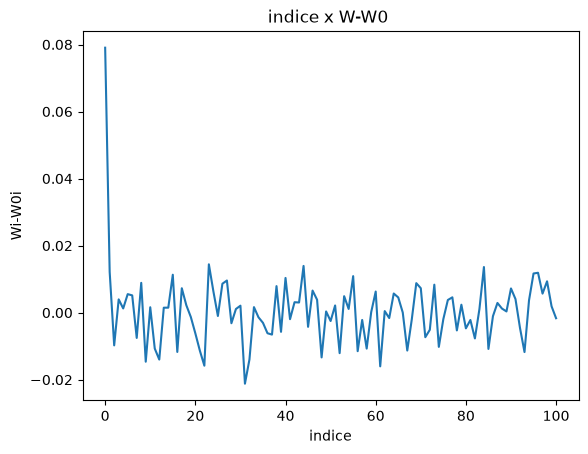

In [67]:
# Exibindo a diferença W-W0 com os indices
plt.plot(np.arange(0, m+1).reshape(-1,1), W-W0)
plt.title("indice x W-W0 ")
plt.xlabel("indice")
plt.ylabel("Wi-W0i")
plt.show()

A partir do gráfico fica ainda mais explicito a aproximação de W0 com W.

In [70]:
erro_final = np.sum((y - X@W0)**2)
print(f"Erro final = {erro_final}") # É o menor segundo o método dos mínimos quadrados

Erro final = 2049.1625323028175


In [89]:
# Mostrando que apenas chutando W0 não é possível adquirir bons resultados
numero_testes = 10
for i in range(1, numero_testes+1):
    W_teste = np.random.uniform(-100,100, (m+1, 1))
    Erro_alternativo = np.sum((y - X@W_teste)**2)
    print(f"{i}° erro = {Erro_alternativo}")
# Serve também para ter uma referência do quando o erro final é pequeno 

1° erro = 214259200746.3509
2° erro = 213152286564.3891
3° erro = 200631864876.67075
4° erro = 217793190139.21375
5° erro = 230055178268.89447
6° erro = 226543665996.48996
7° erro = 245613978854.0155
8° erro = 225382529364.5459
9° erro = 254857138262.28842
10° erro = 249518225009.25757


### 2.4 - Regressão polinomial